In [1]:
import os

# Check what files are inside
for file in os.listdir('/kaggle/input/datasets/shantanusharma23410/heart-disease-csv'):
    print(file)

heart_disease_uci.csv


In [2]:
/#step1 ==Data Cleaning + Target Fix 


import pandas as pd
import numpy as np

# ── 1. Load ──────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/shantanusharma23410/heart-disease-csv/heart_disease_uci.csv')

# ── 2. Basic Info ─────────────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())

# ── 3. Fix Target Column ──────────────────────────────────────────────────
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df.rename(columns={'num': 'target'}, inplace=True)
print("\nTarget Distribution:\n", df['target'].value_counts())

# ── 4. Check Missing Values ───────────────────────────────────────────────
print("\nMissing Values:\n", df.isnull().sum())
print("\nMissing %:\n", (df.isnull().sum() / len(df) * 100).round(2))

# ── 5. Drop Useless Columns ───────────────────────────────────────────────
# 'id' is just a row number — no predictive value
df.drop(columns=['id'], inplace=True, errors='ignore')

# ── 6. Fix Missing Values ─────────────────────────────────────────────────
# Numerical columns → fill with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'target']  # exclude target
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# ── 7. Verify No Missing Values Left ─────────────────────────────────────
print("\nMissing After Cleaning:\n", df.isnull().sum())

# ── 8. Final Shape ────────────────────────────────────────────────────────
print("\nFinal Shape:", df.shape)
print("\nCleaned Data Sample:\n", df.head())

Shape: (920, 16)

Column Names:
 ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data Types:
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

First 5 Rows:
    id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  tha

/tmp/ipykernel_16/3082036609.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_16/3082036609.py:38: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].mode()[0], inplace=True)


In [3]:
df.head()


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
print("Columns:", df.shape[1])
print("Rows:", df.shape[0])
print("\nColumn Names:\n", df.columns.tolist())

Columns: 15
Rows: 920

Column Names:
 ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [5]:
# Split Features & Target
X = df.drop('target', axis=1)
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\ny distribution:\n", y.value_counts())

X shape: (920, 14)
y shape: (920,)

y distribution:
 target
1    509
0    411
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (736, 14)
X_test shape: (184, 14)
y_train shape: (736,)
y_test shape: (184,)


In [7]:
# One Hot Encoding
df = pd.get_dummies(df, drop_first=False)

print(df.shape)
print(df.head())

(920, 28)
   age  trestbps   chol    fbs  thalch  exang  oldpeak   ca  target  \
0   63     145.0  233.0   True   150.0  False      2.3  0.0       0   
1   67     160.0  286.0  False   108.0   True      1.5  3.0       1   
2   67     120.0  229.0  False   129.0   True      2.6  2.0       1   
3   37     130.0  250.0  False   187.0  False      3.5  0.0       0   
4   41     130.0  204.0  False   172.0  False      1.4  0.0       0   

   sex_Female  ...  cp_typical angina  restecg_lv hypertrophy  restecg_normal  \
0       False  ...               True                    True           False   
1       False  ...              False                    True           False   
2       False  ...              False                    True           False   
3       False  ...              False                   False            True   
4        True  ...              False                    True           False   

   restecg_st-t abnormality  slope_downsloping  slope_flat  slope_upsloping 

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/shantanusharma23410/heart-disease-csv/heart_disease_uci.csv')

# Fix target
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Drop unnecessary columns
df = df.drop(['id', 'dataset', 'num'], axis=1)

# One Hot Encoding
df = pd.get_dummies(df, drop_first=False)

# ✅ Fill missing values AFTER encoding
df.fillna(df.median(), inplace=True)

# Verify no missing values
print("Missing values:", df.isnull().sum().sum())

# Split Features & Target
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standard Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Missing values: 0
Accuracy: 0.8206521739130435

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.81      0.79        75
           1       0.87      0.83      0.85       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184


Confusion Matrix:
 [[61 14]
 [19 90]]


In [9]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Compare both models
print("\n--- Model Comparison ---")
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:       ", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8369565217391305

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81        75
           1       0.88      0.83      0.86       109

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.84      0.84       184


Confusion Matrix:
 [[63 12]
 [18 91]]

--- Model Comparison ---
Logistic Regression Accuracy: 0.8206521739130435
Random Forest Accuracy:        0.8369565217391305


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_pred_knn = knn.predict(X_test)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

# Compare all 3 models
print("\n--- Model Comparison ---")
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:      ", accuracy_score(y_test, y_pred_rf))
print("KNN Accuracy:                ", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8369565217391305

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81        75
           1       0.88      0.83      0.86       109

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.84      0.84       184


Confusion Matrix:
 [[63 12]
 [18 91]]

--- Model Comparison ---
Logistic Regression Accuracy: 0.8206521739130435
Random Forest Accuracy:       0.8369565217391305
KNN Accuracy:                 0.8369565217391305


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# Compare all 4 models
print("\n--- Model Comparison ---")
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:      ", accuracy_score(y_test, y_pred_rf))
print("KNN Accuracy:                ", accuracy_score(y_test, y_pred_knn))
print("XGBoost Accuracy:            ", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.842391304347826

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.87      0.82        75
           1       0.90      0.83      0.86       109

    accuracy                           0.84       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.84      0.84       184


Confusion Matrix:
 [[65 10]
 [19 90]]

--- Model Comparison ---
Logistic Regression Accuracy: 0.8206521739130435
Random Forest Accuracy:       0.8369565217391305
KNN Accuracy:                 0.8369565217391305
XGBoost Accuracy:             0.842391304347826


In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# All model predictions
models = {
    'Logistic Regression': lr.predict(X_test),
    'Random Forest'      : rf.predict(X_test),
    'KNN'                : knn.predict(X_test),
    'XGBoost'            : xgb.predict(X_test)
}

# Evaluation
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10} {'AUC-ROC':>10}")
print("-" * 60)

for name, y_pred_model in models.items():
    acc = accuracy_score(y_test, y_pred_model)
    f1  = f1_score(y_test, y_pred_model)
    auc = roc_auc_score(y_test, y_pred_model)
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}")

Model                       Accuracy   F1 Score    AUC-ROC
------------------------------------------------------------
Logistic Regression           0.8207     0.8451     0.8195
Random Forest                 0.8370     0.8585     0.8374
KNN                           0.8370     0.8585     0.8374
XGBoost                       0.8424     0.8612     0.8462


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

models = {
    'Logistic Regression': lr,
    'Random Forest'      : rf,
    'KNN'                : knn,
    'XGBoost'            : xgb
}

for name, model in models.items():
    y_pred_model = model.predict(X_test)
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_model))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_model))
    print("AUC-ROC Score:", roc_auc_score(y_test, y_pred_model))
    print()

  Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.79        75
           1       0.87      0.83      0.85       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184

Confusion Matrix:
[[61 14]
 [19 90]]
AUC-ROC Score: 0.8195107033639144

  Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        75
           1       0.88      0.83      0.86       109

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.84      0.84       184

Confusion Matrix:
[[63 12]
 [18 91]]
AUC-ROC Score: 0.8374311926605505

  KNN

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.

In [15]:
import pickle
from sklearn.metrics import accuracy_score

# Find best model
models = {
    'Logistic Regression': lr,
    'Random Forest'      : rf,
    'KNN'                : knn,
    'XGBoost'            : xgb
}

# Pick best based on accuracy
best_name = max(models, key=lambda name: accuracy_score(y_test, models[name].predict(X_test)))
best_model = models[best_name]

print(f"Best Model: {best_name}")
print(f"Accuracy: {accuracy_score(y_test, best_model.predict(X_test)):.4f}")

# Save best model and scaler
pickle.dump(best_model, open("heart_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\nSaved: heart_model.pkl")
print("Saved: scaler.pkl")

Best Model: XGBoost
Accuracy: 0.8424

Saved: heart_model.pkl
Saved: scaler.pkl


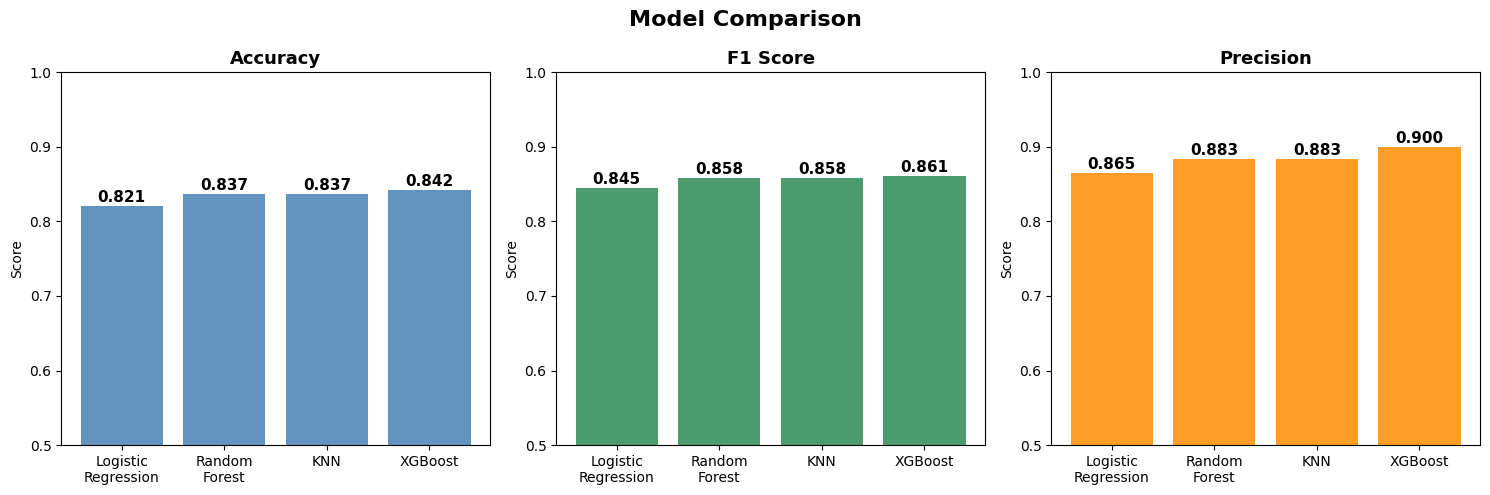

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score

# Model predictions
models = {
    'Logistic\nRegression': lr,
    'Random\nForest'      : rf,
    'KNN'                 : knn,
    'XGBoost'             : xgb
}

# Calculate metrics
names      = list(models.keys())
accuracies = [accuracy_score(y_test, m.predict(X_test))  for m in models.values()]
f1_scores  = [f1_score(y_test, m.predict(X_test))        for m in models.values()]
precisions = [precision_score(y_test, m.predict(X_test)) for m in models.values()]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

metrics = [
    (accuracies, 'Accuracy',  'steelblue'),
    (f1_scores,  'F1 Score',  'seagreen'),
    (precisions, 'Precision', 'darkorange')
]

for ax, (scores, title, color) in zip(axes, metrics):
    bars = ax.bar(names, scores, color=color, alpha=0.85)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel('Score')
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{score:.3f}',
                ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()